In [21]:
!pip install kaggle kagglehub
!pip install tensorflow
import kagglehub
import os
import cv2
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.preprocessing.image import ImageDataGenerator


In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
import os

base_path = "/content/drive/MyDrive/Emotion_Deception_Project"

os.makedirs(base_path, exist_ok=True)
os.makedirs(base_path + "/data", exist_ok=True)
os.makedirs(base_path + "/models", exist_ok=True)
os.makedirs(base_path + "/notebooks", exist_ok=True)
os.makedirs(base_path + "/outputs", exist_ok=True)

print("Folders created successfully")

Folders created successfully


In [4]:
path = kagglehub.dataset_download("msambare/fer2013")

print("Dataset path:", path)

for root, dirs, files in os.walk(path):
    print(root)
    break

Using Colab cache for faster access to the 'fer2013' dataset.
Dataset path: /kaggle/input/fer2013
/kaggle/input/fer2013


In [5]:
dataset_path = path
train_dir = os.path.join(dataset_path, "train")
test_dir = os.path.join(dataset_path, "test")

print("Train folder:", train_dir)
print("Test folder:", test_dir)

Train folder: /kaggle/input/fer2013/train
Test folder: /kaggle/input/fer2013/test


In [6]:
for emotion in sorted(os.listdir(train_dir)):
    count = len(os.listdir(os.path.join(train_dir, emotion)))
    print(emotion, ":", count)

angry : 3995
disgust : 436
fear : 4097
happy : 7215
neutral : 4965
sad : 4830
surprise : 3171


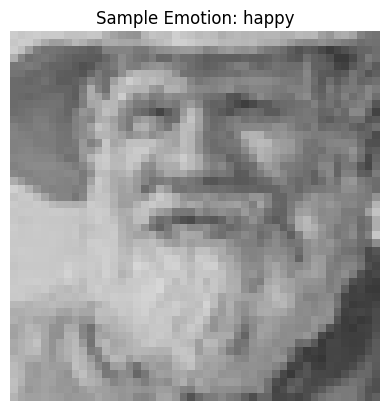

In [7]:
emotion = "happy"

sample_path = os.path.join(train_dir, emotion,
                           os.listdir(os.path.join(train_dir, emotion))[0])

img = cv2.imread(sample_path)

plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
plt.title("Sample Emotion: " + emotion)
plt.axis("off")
plt.show()

{'angry': 3995, 'disgust': 436, 'fear': 4097, 'happy': 7215, 'neutral': 4965, 'sad': 4830, 'surprise': 3171}


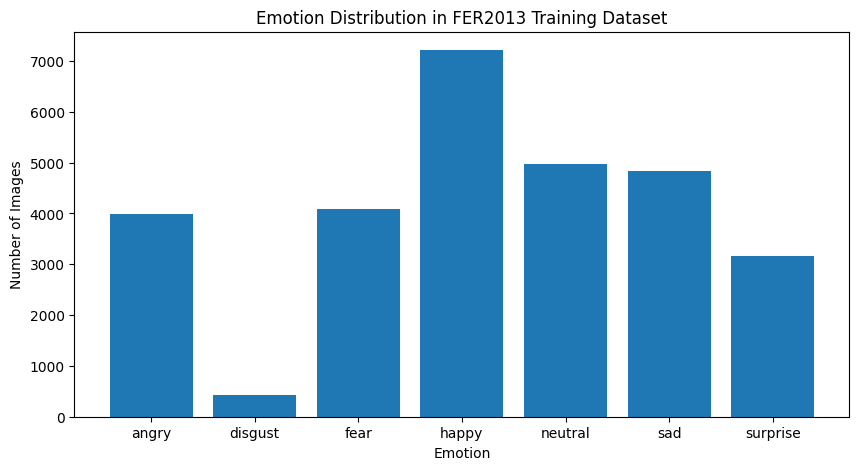

In [8]:
emotion_counts = {}

for emotion in sorted(os.listdir(train_dir)):
    emotion_path = os.path.join(train_dir, emotion)
    emotion_counts[emotion] = len(os.listdir(emotion_path))

print(emotion_counts)

emotions = list(emotion_counts.keys())
counts = list(emotion_counts.values())

plt.figure(figsize=(10,5))
plt.bar(emotions, counts)

plt.title("Emotion Distribution in FER2013 Training Dataset")
plt.xlabel("Emotion")
plt.ylabel("Number of Images")

plt.show()

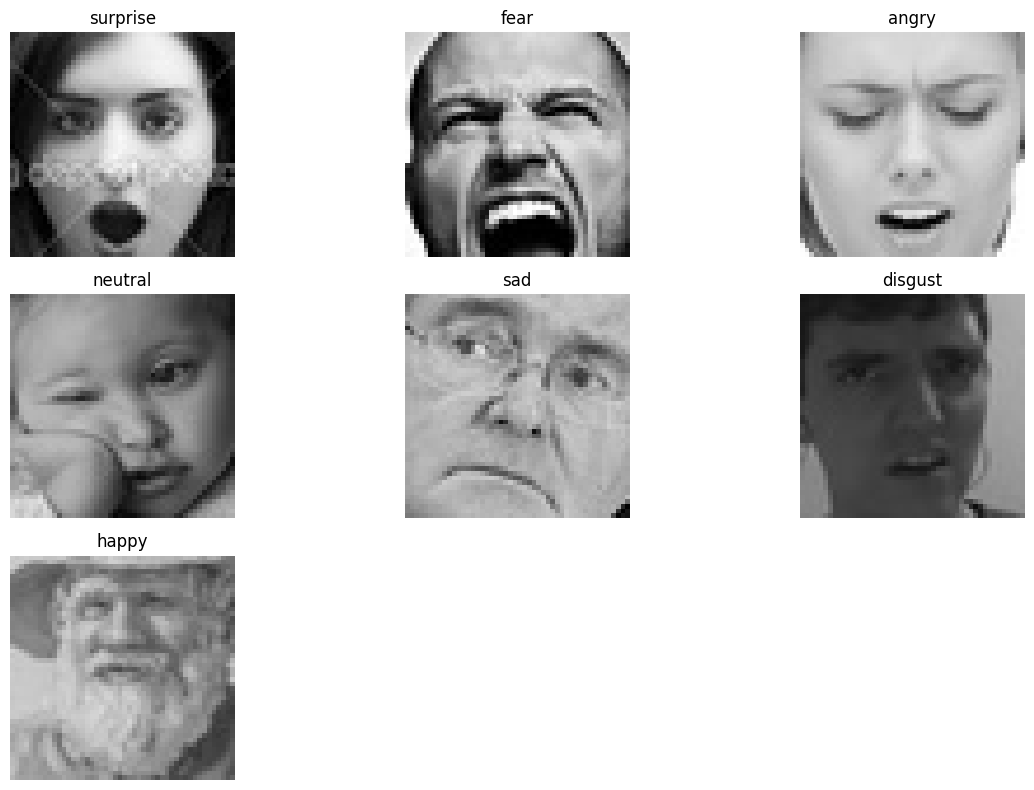

In [9]:
plt.figure(figsize=(12,8))

for i, emotion in enumerate(os.listdir(train_dir)):

    img_path = os.path.join(train_dir, emotion,
                            os.listdir(os.path.join(train_dir, emotion))[0])

    img = cv2.imread(img_path)
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

    plt.subplot(3,3,i+1)
    plt.imshow(img)
    plt.title(emotion)
    plt.axis("off")

plt.tight_layout()
plt.show()

In [10]:
def preprocess_image(image_path):

    img = cv2.imread(image_path)

    # convert to grayscale
    img = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

    # resize
    img = cv2.resize(img, (48,48))

    # normalize
    img = img / 255.0

    return img

(np.float64(-0.5), np.float64(47.5), np.float64(47.5), np.float64(-0.5))

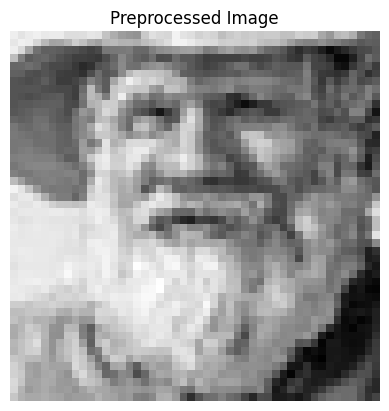

In [11]:
sample_img = preprocess_image(sample_path)

plt.imshow(sample_img, cmap="gray")
plt.title("Preprocessed Image")
plt.axis("off")

In [12]:
emotion_labels = {
    "angry":0,
    "disgust":1,
    "fear":2,
    "happy":3,
    "neutral":4,
    "sad":5,
    "surprise":6
}

In [13]:
def load_dataset(data_dir):

    X = []
    y = []

    for emotion in sorted(os.listdir(data_dir)):

        emotion_path = os.path.join(data_dir, emotion)

        print("Loading:", emotion)

        for img_file in sorted(os.listdir(emotion_path)):

            img_path = os.path.join(emotion_path, img_file)

            img = preprocess_image(img_path)

            X.append(img)
            y.append(emotion_labels[emotion])

    return np.array(X), np.array(y)

In [14]:
X_train, y_train = load_dataset(train_dir)
X_test, y_test = load_dataset(test_dir)

print("X_train shape:", X_train.shape)
print("y_train shape:", y_train.shape)

print("X_test shape:", X_test.shape)
print("y_test shape:", y_test.shape)

Loading: angry
Loading: disgust
Loading: fear
Loading: happy
Loading: neutral
Loading: sad
Loading: surprise
Loading: angry
Loading: disgust
Loading: fear
Loading: happy
Loading: neutral
Loading: sad
Loading: surprise
X_train shape: (28709, 48, 48)
y_train shape: (28709,)
X_test shape: (7178, 48, 48)
y_test shape: (7178,)


In [15]:
X_train = X_train.reshape(-1,48,48,1)
X_test = X_test.reshape(-1,48,48,1)

print(X_train.shape)

(28709, 48, 48, 1)


In [16]:

print("Before encoding:", y_train.shape)

# Only encode if labels are not already one-hot
if len(y_train.shape) == 1:
    y_train = to_categorical(y_train, num_classes=7)
    y_test = to_categorical(y_test, num_classes=7)

print("After encoding:", y_train.shape)

Before encoding: (28709,)
After encoding: (28709, 7)


In [17]:
np.savez("/content/drive/MyDrive/Emotion_Deception_Project/data/fer2013_processed.npz",
         X_train=X_train,
         y_train=y_train,
         X_test=X_test,
         y_test=y_test)

In [18]:
# data = np.load("fer2013_processed.npz")

# X_train = data["X_train"]
# y_train = data["y_train"]
# X_test = data["X_test"]
# y_test = data["y_test"]